In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!git clone https://github.com/nishi-kasat/RI.git
%cd RI

Cloning into 'RI'...
remote: Enumerating objects: 21, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 21 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (21/21), 73.40 KiB | 1.22 MiB/s, done.
Resolving deltas: 100% (3/3), done.
/content/RI


In [3]:
!pip install -q torch torchvision timm scikit-learn pandas matplotlib tensorboard opencv-python seaborn

In [6]:
ZIP_PATH = "/content/drive/MyDrive/Research-Paper/Dataset/state-farm-distracted-driver-detection.zip"
!mkdir -p /content/dataset
!unzip -q "$ZIP_PATH" -d /content/dataset

# Milestone 2: MobileViT-XXS Baseline Training
This notebook implements the baseline training pipeline for distracted driver detection using the MobileViT-XXS architecture.

In [7]:
import os
import time
import json
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Tuple, List, Dict, Any, Optional
from tqdm.auto import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from torchvision import transforms
import timm
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support

# --- Configuration ---
class Config:
    SEED = 42
    DATA_DIR = Path('/content/dataset')
    CSV_PATH = DATA_DIR / 'driver_imgs_list.csv'
    WEIGHTS_DIR = Path('weights/mobilevit')
    OUTPUT_DIR = Path('outputs/training')
    FIGURES_DIR = Path('outputs/figures')
    LOG_DIR = Path('outputs/tensorboard/mobilevit')

    IMAGE_SIZE = 224
    BATCH_SIZE = 32
    EPOCHS = 20
    LR = 1e-4
    WEIGHT_DECAY = 1e-4
    PATIENCE = 5
    NUM_CLASSES = 10
    MODEL_NAME = 'mobilevit_xxs'
    CLASS_NAMES = [f'c{i}' for i in range(10)]

# Initialize paths
for p in [Config.WEIGHTS_DIR, Config.OUTPUT_DIR, Config.FIGURES_DIR, Config.LOG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

def seed_everything(seed: int):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = True

seed_everything(Config.SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [8]:
class DistractedDriverDataset(Dataset):
    def __init__(self, df: pd.DataFrame, root_dir: Path, transform: Optional[Any] = None):
        self.df = df
        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted(df['classname'].unique())
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, int]:
        row = self.df.iloc[idx]
        img_path = self.root_dir / 'imgs' / 'train' / row['classname'] / row['img']
        image = Image.open(img_path).convert('RGB')
        label = self.class_to_idx[row['classname']]
        if self.transform:
            image = self.transform(image)
        return image, label

def get_dataloaders() -> Tuple[DataLoader, DataLoader]:
    df = pd.read_csv(Config.CSV_PATH)
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=Config.SEED)
    train_idx, val_idx = next(gss.split(df, groups=df['subject']))

    train_df = df.iloc[train_idx].reset_index(drop=True)
    val_df = df.iloc[val_idx].reset_index(drop=True)

    train_transform = transforms.Compose([
        transforms.Resize((Config.IMAGE_SIZE, Config.IMAGE_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
        transforms.ColorJitter(0.2, 0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    val_transform = transforms.Compose([
        transforms.Resize((Config.IMAGE_SIZE, Config.IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    train_ds = DistractedDriverDataset(train_df, Config.DATA_DIR, train_transform)
    val_ds = DistractedDriverDataset(val_df, Config.DATA_DIR, val_transform)

    train_loader = DataLoader(train_ds, batch_size=Config.BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_ds, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=2)

    return train_loader, val_loader

In [9]:
class MobileViTTrainer:
    def __init__(self, model: nn.Module, train_loader: DataLoader, val_loader: DataLoader):
        self.model = model.to(device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = optim.AdamW(model.parameters(), lr=Config.LR, weight_decay=Config.WEIGHT_DECAY)
        self.scheduler = optim.lr_scheduler.CosineAnnealingLR(self.optimizer, T_max=Config.EPOCHS)
        self.use_amp = torch.cuda.is_available()
        self.scaler = torch.cuda.amp.GradScaler(enabled=self.use_amp)
        self.writer = SummaryWriter(Config.LOG_DIR)

        self.history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_precision': [], 'val_recall': [], 'val_f1': []}
        self.best_acc = 0.0
        self.patience_counter = 0
        self.start_epoch = 0

    def train_epoch(self, epoch: int) -> Tuple[float, float]:
        self.model.train()
        running_loss, correct, total = 0.0, 0, 0
        pbar = tqdm(self.train_loader, desc=f"Epoch {epoch+1}/{Config.EPOCHS} [Train]")

        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            self.optimizer.zero_grad()

            with torch.cuda.amp.autocast(enabled=self.use_amp):
                outputs = self.model(images)
                loss = self.criterion(outputs, labels)

            self.scaler.scale(loss).backward()
            self.scaler.step(self.optimizer)
            self.scaler.update()

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            pbar.set_postfix({'loss': f"{loss.item():.4f}", 'acc': f"{100.*correct/total:.2f}%"})

        return running_loss/total, 100.*correct/total

    @torch.no_grad()
    def validate(self) -> Dict[str, float]:
        self.model.eval()
        running_loss, correct, total = 0.0, 0, 0
        all_preds, all_labels = [], []

        for images, labels in self.val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = self.model(images)
            loss = self.criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

        precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro', zero_division=0)
        return {
            'loss': running_loss/total,
            'acc': 100.*correct/total,
            'precision': precision,
            'recall': recall,
            'f1': f1
        }

    def fit(self):
        latest_path = Config.WEIGHTS_DIR / 'latest_model.pth'
        if latest_path.exists():
            checkpoint = torch.load(latest_path)
            self.model.load_state_dict(checkpoint['model_state_dict'])
            self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
            self.scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
            self.start_epoch = checkpoint['epoch'] + 1
            self.best_acc = checkpoint.get('best_acc', 0.0)
            self.patience_counter = checkpoint.get('patience_counter', 0)
            self.history = checkpoint.get('history', self.history)
            print(f"Resuming from epoch {self.start_epoch}")

        for epoch in range(self.start_epoch, Config.EPOCHS):
            t_loss, t_acc = self.train_epoch(epoch)
            val_metrics = self.validate()
            self.scheduler.step()

            self.history['train_loss'].append(t_loss); self.history['train_acc'].append(t_acc)
            self.history['val_loss'].append(val_metrics['loss']); self.history['val_acc'].append(val_metrics['acc'])
            self.history['val_precision'].append(val_metrics['precision']); self.history['val_recall'].append(val_metrics['recall'])
            self.history['val_f1'].append(val_metrics['f1'])

            self.writer.add_scalar('Loss/Train', t_loss, epoch)
            self.writer.add_scalar('Accuracy/Train', t_acc, epoch)
            self.writer.add_scalar('Loss/Val', val_metrics['loss'], epoch)
            self.writer.add_scalar('Accuracy/Val', val_metrics['acc'], epoch)
            self.writer.add_scalar('Precision/Val', val_metrics['precision'], epoch)
            self.writer.add_scalar('Recall/Val', val_metrics['recall'], epoch)
            self.writer.add_scalar('F1/Val', val_metrics['f1'], epoch)

            checkpoint = {
                'epoch': epoch,
                'model_state_dict': self.model.state_dict(),
                'optimizer_state_dict': self.optimizer.state_dict(),
                'scheduler_state_dict': self.scheduler.state_dict(),
                'best_acc': self.best_acc,
                'patience_counter': self.patience_counter,
                'history': self.history
            }
            torch.save(checkpoint, latest_path)

            if val_metrics['acc'] > self.best_acc:
                self.best_acc = val_metrics['acc']
                torch.save(self.model.state_dict(), Config.WEIGHTS_DIR / 'best_model.pth')
                self.patience_counter = 0
            else:
                self.patience_counter += 1

            if self.patience_counter >= Config.PATIENCE:
                print("Early stopping triggered."); break

        pd.DataFrame(self.history).to_csv(Config.OUTPUT_DIR / 'training_history.csv', index=False)
        self.writer.close()

In [13]:
# Model Building & Execution
train_loader, val_loader = get_dataloaders()
model = timm.create_model(Config.MODEL_NAME, pretrained=True, num_classes=Config.NUM_CLASSES)
trainer = MobileViTTrainer(model, train_loader, val_loader)

trainer.fit()

/tmp/ipykernel_934/1994065317.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(enabled=self.use_amp)


Epoch 1/20 [Train]:   0%|          | 0/546 [00:00<?, ?it/s]

/tmp/ipykernel_934/1994065317.py:27: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=self.use_amp):


Epoch 2/20 [Train]:   0%|          | 0/546 [00:00<?, ?it/s]

/tmp/ipykernel_934/1994065317.py:27: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=self.use_amp):


...

Epoch 8/20 [Train]:   0%|          | 0/546 [00:00<?, ?it/s]

/tmp/ipykernel_934/1994065317.py:27: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=self.use_amp):


Epoch 9/20 [Train]:   0%|          | 0/546 [00:00<?, ?it/s]

/tmp/ipykernel_934/1994065317.py:27: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=self.use_amp):
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d75216209a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d75216209a0>
Traceback (most recent call last):
  File

Early stopping triggered.


### Evaluation & Visualization
Run the following code after training to generate metrics and plots.

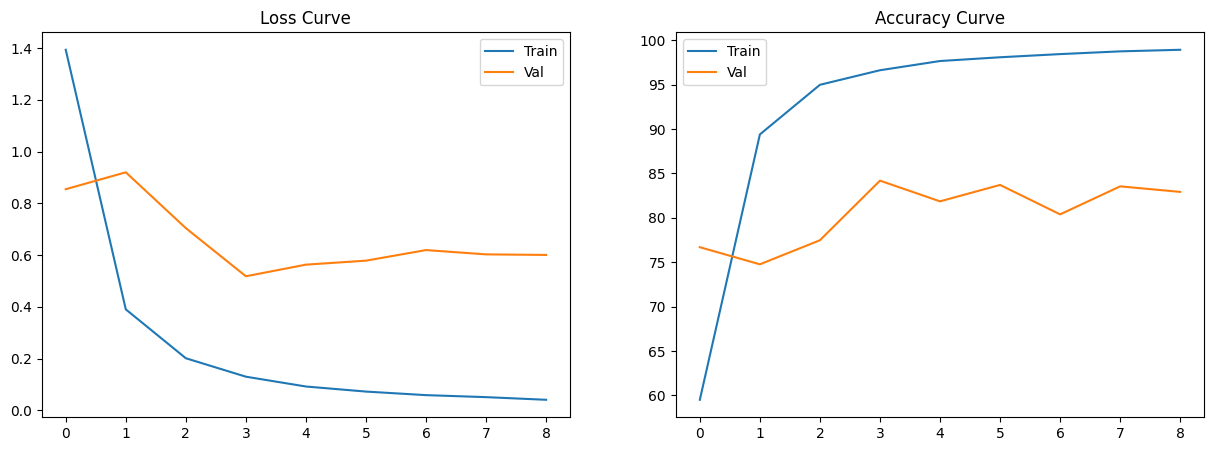

              precision    recall  f1-score   support

          c0       0.76      0.78      0.77       564
          c1       0.93      0.93      0.93       474
          c2       0.71      0.88      0.79       501
          c3       0.97      0.97      0.97       536
          c4       0.91      0.96      0.93       531
          c5       0.96      0.87      0.91       526
          c6       0.84      0.75      0.79       530
          c7       0.96      0.82      0.88       480
          c8       0.65      0.82      0.73       400
          c9       0.77      0.61      0.68       436

    accuracy                           0.84      4978
   macro avg       0.85      0.84      0.84      4978
weighted avg       0.85      0.84      0.84      4978



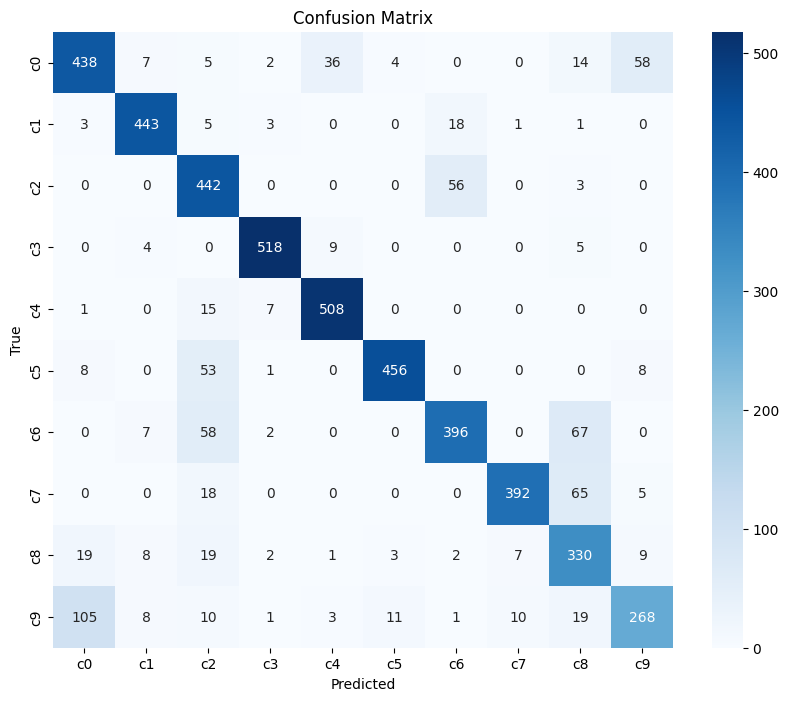

Milestone 2 Completed Successfully


In [16]:
def plot_metrics():
    history = pd.read_csv(Config.OUTPUT_DIR / 'training_history.csv')
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    ax[0].plot(history['train_loss'], label='Train'); ax[0].plot(history['val_loss'], label='Val')
    ax[0].set_title('Loss Curve'); ax[0].legend()
    ax[1].plot(history['train_acc'], label='Train'); ax[1].plot(history['val_acc'], label='Val')
    ax[1].set_title('Accuracy Curve'); ax[1].legend()
    plt.savefig(Config.FIGURES_DIR / 'training_curves.png'); plt.show()

@torch.no_grad()
def final_evaluation():
    model.load_state_dict(torch.load(Config.WEIGHTS_DIR / 'best_model.pth'))
    model.eval()
    y_true, y_pred = [], []
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        y_true.extend(labels.tolist())
        y_pred.extend(outputs.argmax(1).cpu().tolist())

    report = classification_report(y_true, y_pred, target_names=Config.CLASS_NAMES)
    print(report)
    with open(Config.OUTPUT_DIR / 'classification_report.txt', 'w') as f:
        f.write(report)

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=Config.CLASS_NAMES, yticklabels=Config.CLASS_NAMES)
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.savefig(Config.FIGURES_DIR / 'confusion_matrix.png'); plt.show()

plot_metrics()
final_evaluation()

print("Milestone 2 Completed Successfully")

In [17]:
import json
import os

nb_path = "/content/RI/notebooks/02_mobilevit_training.ipynb"

if os.path.exists(nb_path):
    with open(nb_path, "r", encoding="utf-8") as f:
        nb = json.load(f)

    for i, cell in enumerate(nb["cells"]):
        print("=" * 100)
        print(f"CELL {i} - {cell['cell_type']}")
        print("=" * 100)
        print("".join(cell["source"]))
        print("\n")
else:
    print(f"File not found: {nb_path}. Checking directory contents...")
    !ls -R /content/RI

File not found: /content/RI/notebooks/02_mobilevit_training.ipynb. Checking directory contents...
/content/RI:
notebooks  outputs  weights

/content/RI/notebooks:
01_dataset_preparation.ipynb

/content/RI/outputs:
figures  tensorboard  training

/content/RI/outputs/figures:
confusion_matrix.png  training_curves.png

/content/RI/outputs/tensorboard:
mobilevit

/content/RI/outputs/tensorboard/mobilevit:
events.out.tfevents.1783418115.59b4214741e0.934.0
events.out.tfevents.1783418848.59b4214741e0.934.1

/content/RI/outputs/training:
classification_report.txt  training_history.csv

/content/RI/weights:
mobilevit

/content/RI/weights/mobilevit:
best_model.pth	latest_model.pth


In [19]:
!zip -r Milestone2_Outputs_Weights.zip weights outputs

  adding: weights/ (stored 0%)
  adding: weights/mobilevit/ (stored 0%)
  adding: weights/mobilevit/latest_model.pth (deflated 9%)
  adding: weights/mobilevit/best_model.pth (deflated 9%)
  adding: outputs/ (stored 0%)
  adding: outputs/figures/ (stored 0%)
  adding: outputs/figures/training_curves.png (deflated 9%)
  adding: outputs/figures/confusion_matrix.png (deflated 14%)
  adding: outputs/training/ (stored 0%)
  adding: outputs/training/training_history.csv (deflated 48%)
  adding: outputs/training/classification_report.txt (deflated 73%)
  adding: outputs/tensorboard/ (stored 0%)
  adding: outputs/tensorboard/mobilevit/ (stored 0%)
  adding: outputs/tensorboard/mobilevit/events.out.tfevents.1783418115.59b4214741e0.934.0 (deflated 9%)
  adding: outputs/tensorboard/mobilevit/events.out.tfevents.1783418848.59b4214741e0.934.1 (deflated 60%)
